In [34]:
# functions nessersary 
import numpy as np
import math 

# Converts Euler angles ([rx, ry, rz] in deg) to a 3x3 rotation matrix
def EulerToRMat(Euler):

    sx = math.sin(Euler[0]);
    sy = math.sin(Euler[1]);
    sz = math.sin(Euler[2]);
    cx = math.cos(Euler[0]);
    cy = math.cos(Euler[1]);
    cz = math.cos(Euler[2]);

    RMat = np.eye(3);
    RMat[0,0] = cy*cz;
    RMat[0,1] = sx*sy*cz-cx*sz;
    RMat[0,2] = cx*sy*cz+sx*sz;
    RMat[1,0] = cy*sz;
    RMat[1,1] = sx*sy*sz+cx*cz;
    RMat[1,2] = cx*sy*sz-sx*cz;
    RMat[2,0] = -sy;
    RMat[2,1] = sx*cy;
    RMat[2,2] = cx*cy;

    return RMat

# Converts a 3x3 rotation matrix to a quaternion
def RMatToQuat(RMat):

    quat = np.zeros((4,1));

    # abs is to avoid rounding errors in the sqrt - it shouldn't be negative anyway
    quat[0] = 0.5 * math.sqrt(abs(1 + RMat[0,0] + RMat[1,1] + RMat[2,2]));

    if (RMat[2,1] - RMat[1,2] > 0):
        quat[1] = 0.5 * math.sqrt(abs(1 + RMat[0,0] - RMat[1,1] - RMat[2,2]));
    else:
        quat[1] = -0.5 * math.sqrt(abs(1 + RMat[0,0] - RMat[1,1] - RMat[2,2]));


    if (RMat[0,2] - RMat[2,0] > 0):
        quat[2] = 0.5 * math.sqrt(abs(1 - RMat[0,0] + RMat[1,1] - RMat[2,2]));
    else:
        quat[2] = -0.5 * math.sqrt(abs(1 - RMat[0,0] + RMat[1,1] - RMat[2,2]));

    if (RMat[1,0] - RMat[0,1] > 0):
        quat[3] = 0.5 * math.sqrt(abs(1 - RMat[0,0] - RMat[1,1] + RMat[2,2]));
    else:
        quat[3] = -0.5 * math.sqrt(abs(1 - RMat[0,0] - RMat[1,1] + RMat[2,2]));

    return quat

# caclulating difference in Quaternions angles 
def quatDiff(q1, q2):
        
    # Difference: qd = q2 * q1c (q1c = conjugate of q1 = inverse of q1)
    # qd = (w2 + i.x2 + j.y2 + k.z2)(w1 - i.x1 - j.y1 - k.z1)
    # qd = w1.w2 - i.x1.w2 - j.y1.w2 - k.z1.w2 + i.w1.x2 - i^2.x1.x2 - ij.y1.x2 - ik.z1.x2 + j.w1.y2 - ji.x1.y2 - j^2.y1.y2 - jk.z1.y2 + k.w1.z2 - ki.x1.z2 - kj.y1.z2 - k^2.z1.z2
    # qd(1) =  w1.w2 + x1.x2 + y1.y2 + z1.z2
    # qd(2) = -x1.w2 + w1.x2 - z1.y2 + y1.z2
    # qd(3) = -y1.w2 + z1.x2 + w1.y2 - x1.z2
    # qd(4) = -z1.w2 - y1.x2 + x1.y2 + w1.z2

    qd = np.zeros((4,1));
    qd[0] =  q1[0]*q2[0] + q1[1]*q2[1] + q1[2]*q2[2] + q1[3]*q2[3]
    qd[1] = -q1[1]*q2[0] + q1[0]*q2[1] - q1[3]*q2[2] + q1[2]*q2[3]
    qd[2] = -q1[2]*q2[0] + q1[3]*q2[1] + q1[0]*q2[2] - q1[1]*q2[3]
    qd[3] = -q1[3]*q2[0] - q1[2]*q2[1] + q1[1]*q2[2] + q1[0]*q2[3]

    a = 2 * np.arccos(np.float32(qd[0]))

    a = abs(a);

    return a, qd

# normalisation function between -1 and +1  
def normalise(x, min_val, max_val):

    # equation for normalisation 
    x_n = (2 * (x - min_val) / (max_val - min_val)) - 1

    return x_n 

In [35]:
## creating an environment class (child class to gym.Env) for the Ultrasound Robot
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import pybullet as p 
import pybullet_utils.bullet_client as bullet_client
import random
import math
import matplotlib.pyplot as plt
import time
from pathlib import Path

class RightArmRobot(gym.Env):
    """
    Custom Environment that follows gym interface.
    """

    # (old comment) Because of google colab, we cannot implement the GUI ('human' render mode)
    metadata = {"render_modes": ["human", "rgb_array"], "simulation_fps": 50} # PyBullet simulation FPS

    def __init__(self, render_mode="human"):

        # calls constructor of parent class gym.Env         
        super(RightArmRobot, self).__init__()
        
        # setting up the render mode for visualisation 
        self.render_mode = render_mode

        # Initialize PyBullet client ID
        self._physics_client_id = -1  
        
        # initialsiing the action space as continous (action is angles of all 9 motorised joints) 
        self.action_space = spaces.Box(low=-1, high=1, shape=(10,), dtype=np.float32) # change to 10 once URDF is updated 
        # initialising the observation space as continous (observation is cartesian coordiantes of final joint in the robot)
        self.observation_space = spaces.Box(low = -10, high = 10, shape=(19,), dtype=np.float32)

        # tolerance for goal completion (position)
        self.pos_tol = 0.02

        # tolerance for goal completion (orientation)
        self.orient_tol = 0.2

        # initalising step number 
        self.step_number = 0

        # initalising the episode number 
        self.episode_number = 0 

        # initalise the max step number 
        self.max_step_size = 100

        # rest function called to properly initalise the 
        self.reset()

    def reset(self, seed=None, options=None):

        # re-initalisation of environment after truncation, termination or initalisation

        # reset step number and print
        self.step_number = 0

        # increase the episode number 
        self.episode_number += 1

        # initalising the prev Euclidean distance
        self.prev_Euclid_dist = 0

        # calls constructor of parent class gym.Env 
        super().reset(seed=seed, options=options)

        # random number generator to provide new target for the robot to move to (set limits)
        self.x_target = random.random()*(0.15 - -0.10) 
        self.y_target = random.random()*(0.65 - 0.3) + (0.3) 
        self.z_target = random.random()*(0.35 - 0.15) + (0.15) 
        self.pos_target = np.array([self.x_target, self.y_target, self.z_target], dtype=np.float32)

        # New ORIENTATION target (in Euler angles) for the robot to move to (set limits)
        self.x_euler_t = random.random()*(-0.785398 - -2.35619)
        self.y_euler_t = random.random()*(0.785398 - -0.785398)
        self.z_euler_t = random.random()*(math.pi - -math.pi)
        self.euler_t = np.array([self.x_euler_t, self.y_euler_t, self.z_euler_t])

        # Converting the target Euler angles into Matrix 
        self.Mat_t = EulerToRMat(self.euler_t)
        # Converting the target Matrix into Quaternion
        self.Quat_t = RMatToQuat(self.Mat_t)
        
        # setup PyBullet client 
        if self._physics_client_id < 0:
            # create BulletClient 
            if self.render_mode == "human":
                self._bullet_client = bullet_client.BulletClient(connection_mode=p.DIRECT)
            else:
                self._bullet_client = bullet_client.BulletClient()
            self._physics_client_id = self._bullet_client._client

        # setting up PyBullet simulation 
        self._bullet_client.resetSimulation()
        self._bullet_client.setGravity(0, 0, -9.8)
        self._bullet_client.setTimeStep(1.0 / self.metadata["simulation_fps"])

        # load robot 
        robot_dir = Path.cwd() / "Housden created STL and URDF 5"
        urdf_path = robot_dir / "RightArm.urdf"
        self._bullet_client.setAdditionalSearchPath(str(robot_dir))
        self.RightArmRobot = self._bullet_client.loadURDF(str(urdf_path),[0, 0, 0], useFixedBase=True)

        # check if loading of the robot was sucessful 
        if self.RightArmRobot < 0:
            raise FileNotFoundError("Failed to load kuka_3.urdf. Check the file path.")

        # Check the number of joints
        self.num_joints = self._bullet_client.getNumJoints(self.RightArmRobot)

        # Validate link index
        link_index = 9
        if link_index >= self.num_joints:
            raise IndexError(f"Invalid link index {link_index}. Max index is {self.num_joints - 1}.")

        # Get link state
        link_state = self._bullet_client.getLinkState(self.RightArmRobot, link_index)
        if link_state is None:
            raise RuntimeError(f"Failed to get link state for link {link_index}.")

        # Find and print link information (for debugging)
        #for i in range(num_joints):
             #joint_name = self._bullet_client.getJointInfo(self.RightArmRobot, i)[12].decode('utf-8')  # Get joint name
             #link_index = self._bullet_client.getJointInfo(self.RightArmRobot, i)[16] # Get link index
             #if link_index != -1: # if the joint has an associated link
                 #link_name = self._bullet_client.getLinkInfo(self.RightArmRobot,link_index)[0].decode('utf-8')
                #print(f"Joint {i}: {joint_name}, Link index: {link_index}, Link Name: {link_name}")

        # get the position of link of interst 
        link_index = self.num_joints - 1 
        
        link_state = self._bullet_client.getLinkState(self.RightArmRobot, link_index)
        
        # extracting the x y z position 
        self.position = np.array(link_state[0], dtype=np.float32)

        # extracting the orientation as a Quaternion
        self.orientation = np.array(link_state[1], dtype=np.float32)

        # calculating initial distances from the targets 
        self.Euclid_dist = math.dist(self.position, self.pos_target)
        # calculating angular differences from targets 
        self.Quaternion_diff = quatDiff(self.orientation, self.Quat_t)
        self.Quat_diff_angle = self.Quaternion_diff[0]
        self.Quat_diff_Q = self.Quaternion_diff[1]

        # normalising position such that observations are more easily computeable in RL neural networks
        # normalising target positions 
        self.x_target_n = normalise(self.x_target, -0.10, 0.15)
        self.y_target_n = normalise(self.y_target, 0.3, 0.65)
        self.z_target_n = normalise(self.z_target, 0.15, 0.35)
        self.pos_target_n = np.array([self.x_target_n, self.y_target_n, self.z_target_n], dtype=np.float32)
        # normalising actual positions 
        self.x_pos_n = normalise(self.position[0], -0.10, 0.15)
        self.y_pos_n = normalise(self.position[1], 0.3, 0.65)
        self.z_pos_n = normalise(self.position[2], 0.15, 0.35)
        self.pos_n = np.array([self.x_pos_n, self.y_pos_n, self.z_pos_n], dtype=np.float32)
        
        # self.observation MUST be a numpy array 
        # observation is the euclidean distance, the quaternion difference, the target positions, the current positions,target orientation, current orientation 
        self.observation = np.concatenate([np.array([self.Euclid_dist], dtype=np.float32), np.array([self.Quat_diff_Q], dtype=np.float32).flatten(), self.pos_target_n.flatten(), self.pos_n.flatten(), self.orientation.flatten(), self.Quat_t.flatten()]).astype(np.float32)
        
        return self.observation, {}
        

    def step(self, action):

        # takes an action in a given state

        # updating the step counter each step and printing
        self.step_number += 1

        # initalising the scaled action variable to have the dimensions of the actions 
        scaled_action = action

        # scale action by pi 
        for i in range(10):
            if (i == 0):
                scaled_action[i] = action[i] / 4
            else:
                scaled_action[i] = action[i] * np.pi 

        # applying dependent joint constraint (change to 1-2 when URDF is updated)
        scaled_action[2] = -scaled_action[1]
        
        # Apply action to robot
        for i in range(10):  # change to 10 when URDF is updated 
            self._bullet_client.setJointMotorControl2(
                self.RightArmRobot, i, p.POSITION_CONTROL, targetPosition=scaled_action[i]
                )
        # use for loop for updating to ensure that the robot can move by the amount it needs to move 
        for _ in range(3):
            # Robots new position is updated in the simulation  
            self._bullet_client.stepSimulation()
        
        # Gives position of the final link of the Robot in Cartesian space
        link_state = self._bullet_client.getLinkState(self.RightArmRobot, self.num_joints-1)
        
        # Position and orienatation are the observation to be changed 
        self.position = np.array(link_state[0], dtype=np.float32)
        self.orientation = np.array(link_state[1], dtype=np.float32)

        # normalising actual positions 
        self.x_pos_n = normalise(self.position[0], -0.10, 0.15)
        self.y_pos_n = normalise(self.position[1], 0.3, 0.65)
        self.z_pos_n = normalise(self.position[2], 0.15, 0.35)
        self.pos_n = np.array([self.x_pos_n, self.y_pos_n, self.z_pos_n], dtype=np.float32)

        # calculating the Euclidian distance for reward calculation
        self.Euclid_dist = math.dist(self.position, self.pos_target)
        # calculating the Quaternion difference for reward calculation 
        self.Quaternion_diff = quatDiff(self.orientation, self.Quat_t)
        self.Quat_diff_angle = self.Quaternion_diff[0].item()
        self.Quat_diff_Q = self.Quaternion_diff[1]

        # observation is the euclidean distance, the quaternion difference, the target positions, the current positions,target orientation, current orientation 
        self.observation = np.concatenate([np.array([self.Euclid_dist], dtype=np.float32), np.array([self.Quat_diff_Q], dtype=np.float32).flatten(), self.pos_target_n.flatten(), self.pos_n.flatten(), self.orientation.flatten(), self.Quat_t.flatten()]).astype(np.float32)
        # new observation stored in variable obs  
        obs = self.observation

        # normalising the Euclidean distance to 0-1 (dividing by maximum Euclidean distance)
        self.Euclid_dist_n = (self.Euclid_dist / 0.7533)

        # normalising the angular difference to 0-1 (dividing by the radians)
        self.Quat_diff_angle_n = self.Quat_diff_angle / (2 * np.pi)
        
        # calculating the reward (L1 norm of the Euclidean distance and the Quaternion difference)
        reward = -(self.Euclid_dist_n + self.Quat_diff_angle_n)
        
        # collect as a prev Euclidean Distance 
        self.prev_Euclid_dist = self.Euclid_dist

        # convergence criteria 
        if ((self.Euclid_dist < self.pos_tol) and (self.Quat_diff_angle < self.orient_tol)):
            # large reward for termination 
            reward += 100
            print("Terminated")
            print("Target position x: ", self.x_target)
            print("Target position y: ", self.y_target)
            print("Target position z: ", self.z_target)
            terminated = True 
        else:
            terminated = False 
        
        # truncation criteria
        if (self.step_number < self.max_step_size):          
            truncated = False
        else:
            truncated = True 
            
        # updating the info dictionary 
        info = {"Truncated":truncated, "Terminated":terminated,"Observations":obs,"AngleDiff":self.Quat_diff_angle}            
        
        # returning all step variables in a tuple 
        return obs, reward, terminated, truncated, info

In [36]:
# defining the custom callback 
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.evaluation import evaluate_policy

class CustomCallback(BaseCallback):
    
    # initalisation of callback 
    def __init__(self, log_dir=None, verbose: int = 0):
        super().__init__(verbose)
        
        # initalisation of variables 
        self.timesteps = 0
        self.cum_rewards = 0
        self.episode_rewards = []
        self.number_of_episodes = 0
        self.log_dir = log_dir
        self.terminations = 0
        self.episode_timesteps = 0
        self.episode_termination = []
        self.final_Euclid_dists = []
        self.change_Euclid_dists = []
        self.final_Quat_diffs = []
        self.change_Quat_diffs = []
        self.mean_rewards = []
        self.std_rewards = [] 
        self.num_term_per_100 = 0
        self.num_term_per_100_L = []
        
    def _on_step(self) -> bool:

        # extracting info dictionary 
        info = self.locals["infos"][0]

        # extracting the Euclidean distance 
        Observations = info.get("Observations")
        Euclid_dist = Observations[0]
        Quat_diff = info.get("AngleDiff")
        
        # checking to see if it is the first timestep 
        if (self.episode_timesteps == 0):
           self.initial_Euclid_dist = Euclid_dist  
           self.initial_Quat_diff = Quat_diff
        
        # update the timestep counter
        self.timesteps += 1
        self.episode_timesteps += 1

        # Access the "dones" array, which contains termination flags
        if "dones" in self.locals:
            done = self.locals["dones"][0]  # Extract first element (assuming non-parallel env)
        else:
            raise KeyError("Missing 'dones' in self.locals. Check environment compatibility.")

        # see whether the episode has finished  
        if done:
            
            # appending the episode number counter 
            self.number_of_episodes += 1
            # appending the episode reward counter
            self.episode_rewards.append(self.cum_rewards)
            # resetting the cumulative reward counter to 0 
            self.cum_rewards = 0
            self.episode_timesteps = 0

            # recording the final Euclidean distance
            self.final_Euclid_dists.append(Euclid_dist)

            # recording the final Quaternion difference 
            self.final_Quat_diffs.append(Quat_diff)

            # calculating and recording the change in Euclidean distance 
            change_Euclid_dist = Euclid_dist - self.initial_Euclid_dist 
            self.change_Euclid_dists.append(change_Euclid_dist)

            # calculating and recording the change in Quaternion difference
            change_Quat_diff = Quat_diff - self.initial_Quat_diff
            self.change_Quat_diffs.append(change_Quat_diff)
            
            # checking to see if robot reached target
            info = self.locals["infos"][0]
            if info.get("Terminated") is True:
                self.terminations += 1 
                self.num_term_per_100 += 1
                self.episode_termination.append(self.number_of_episodes)

            # checking if 100,000 timesteps is reached 
            if (self.timesteps % 100000 == 0): 
                # evaluating policy 
                mean_reward, std_reward = evaluate_policy(self.model, self.training_env, n_eval_episodes=100)
                self.mean_rewards.append(mean_reward)
                self.std_rewards.append(std_reward)
                self.num_term_per_100_L.append(self.num_term_per_100)
                

        
        # record the reward of the step taken 
        reward = self.locals["rewards"]
        self.cum_rewards += reward
            
        return True 

    def _on_training_end(self) -> None:

        # Save episode rewards to a text file
        #with open("trial1.txt", "w") as file:
        #    for reward in self.episode_rewards:
        #        file.write(f"{reward}\n")

        # save rewards to text file
        np.savetxt('reward_j.txt', np.array(self.episode_rewards))

        # save final Euclidean distance as text file 
        np.savetxt('fEuclid_j.txt', np.array(self.final_Euclid_dists))

        # save change in Euclidean distance as text file 
        np.savetxt('cEuclid_j.txt', np.array(self.change_Euclid_dists))

        # save final Quaternion diff as text file 
        np.savetxt('fQuat_j.txt', np.array(self.final_Quat_diffs))

        # save change in Quaternion diff as text file 
        np.savetxt('cQuat_j.txt', np.array(self.change_Quat_diffs))

        # save mean reward values
        np.savetxt('mreward_j.txt', np.array(self.mean_rewards))

        # save std reward values 
        np.savetxt('std_rew_j.txt', np.array(self.std_rewards))

        # save number of terms per 100,000
        np.savetxt('num_term_per_100_j', np.array(self.num_term_per_100_L))
        
        # printing the number of terminations and the number of total episodes
        print("Number of episodes: ", self.number_of_episodes)
        print("Number of terminations: ", self.terminations)

        # plotting graphs
        plt.figure(figsize=(15,5))

        # rewards vs episode number 
        plt.subplot(2,3,1)
        plt.plot(self.episode_rewards)
        plt.xlabel("Number of Episodes")
        plt.ylabel("Cumulative Reward")
        plt.title("Cummalative Rewards VS Episode Number")

        # final Euclidean distance vs episode number 
        plt.subplot(2,3,2)
        plt.plot(self.final_Euclid_dists)
        plt.xlabel("Number of Episodes")
        plt.ylabel("Final Euclidean Distance (m)")
        plt.title("Final Euclidean Distance VS Episode Number")

        # change in Euclidean distance vs episode number 
        plt.subplot(2,3,3)
        plt.plot(self.change_Euclid_dists)
        plt.xlabel("Number of Episodes")
        plt.ylabel("Change in Euclidean Distance (m)")
        plt.title("Change in Euclidean Distance VS Episode Number")

        # final Quaternion difference vs episode number 
        plt.subplot(2,3,4)
        plt.plot(self.final_Quat_diffs)
        plt.xlabel("Number of Episodes")
        plt.ylabel("Final Quaternion Difference (rad)")
        plt.title("Final Quaternion Difference VS Episode Number")

        # change in Quaternion Difference vs episode number 
        plt.subplot(2,3,5)
        plt.plot(self.change_Quat_diffs)
        plt.xlabel("Number of Episodes")
        plt.ylabel("Change in Quaternion Difference (rad)")
        plt.title("Change in Quaternion Difference VS Episode Number")

        plt.tight_layout()
        plt.show

In [37]:
# wrapping environment 
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor
import os

# instantating arrayy containing the mean rewards and standard deviation to be computed at the end of each set of 100,000 steps 
mean_rewards_arr = np.array(range(10))
std_rewards_arr = np.array(range(10))

# instantiate the robot arm custom environment and wrap with a monitor wrapper  
env = Monitor(RightArmRobot())

argv[0]=


In [38]:
# checking the environment 
# If the environment don't follow the interface, an error will be thrown
check_env(env, warn=True)

Number of episodes:  10
Number of terminations:  0


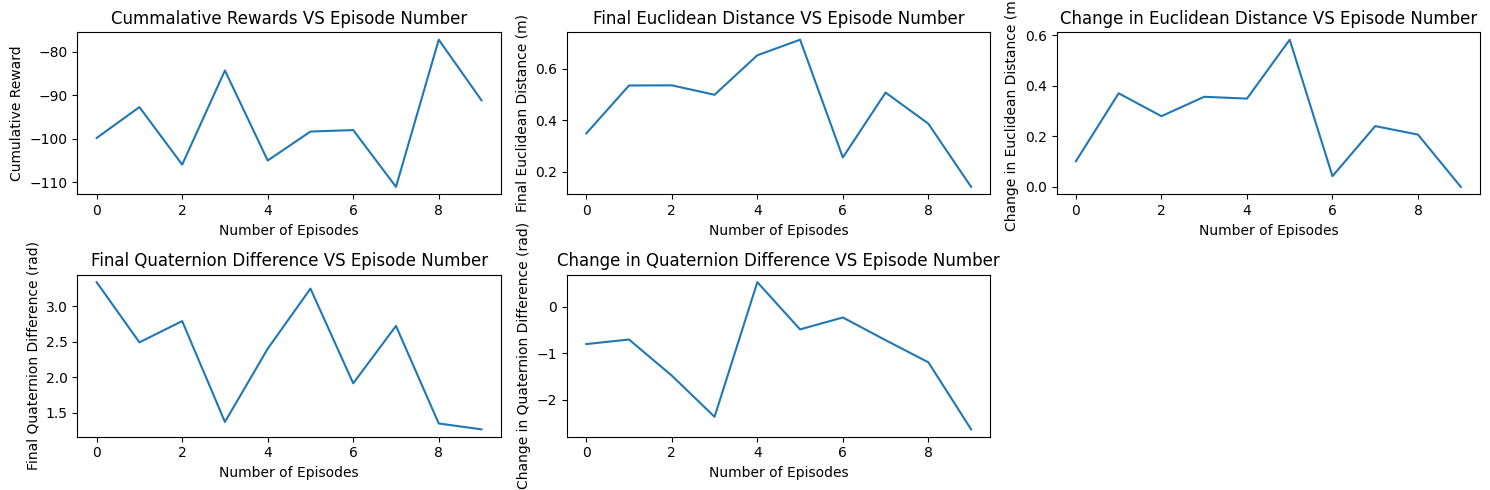

In [39]:
# training Agent 
from stable_baselines3 import SAC
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Instantiate the callback
plotting_callback = CustomCallback()

# training SAC model for the custom environment  
model = SAC("MlpPolicy", env, verbose=0).learn(total_timesteps=1000, callback=plotting_callback)

# saving the model and replay buffer after the training 
model.save("6milR1model")
model.save_replay_buffer("6milR1replaybuffer")


In [40]:
p.disconnect()